# MITSUI&CO. Commodity Prediction Challenge Japanese Tutorial (日本語チュートリアル)

## MITSUI&CO. Commodity Prediction Challenge 概要

**MITSUI&CO. Commodity Prediction Challenge** は、歴史的な市場データから将来のコモディティ（商品）リターンを予測するモデルを構築するKaggleコンペティションです。

### コンペ概要
- **目的**: 正確かつ安定したコモディティ価格予測モデルの開発  
- **データ概要**:  
  - ロンドン金属取引所（LME）をはじめ、日本・米国市場、為替市場などの金融時系列データを収録  
  - 特徴量は約 **1,977カラム**  
  - 予測対象は単一商品のリターンや商品ペアの差分など、約 **424種類のターゲット**  
  - **ラグ処理**（1〜4日先の予測）を含み、休日や金融機関の処理遅延を考慮  
- **評価方法**:  
  - モデルの真の評価はコンペ終了後に行われるため、現在のリーダーボード順位は必ずしも最終結果を反映しない点に注意  

### このノートブックについて
本ノートブックでは、コンペティションへの参加を目的とした基礎的なアプローチを示します。

1. **データの読み込みと前処理**  
2. **探索的データ解析 (EDA)** を通じたデータ構造の把握  
3. **基礎モデルの実装** 
4. **性能評価と改善の方向性**の検討  

### 今後の発展可能性
- 特徴量エンジニアリングによる精度向上  
- アンサンブル手法の活用  
- 市場特性に基づくドメイン知識の導入  

> 本コンペではリーダーボードに一喜一憂するのではなく、安定的かつ汎用性の高いモデル構築を目指すことが重要です。

## 初期処理
- ライブラリのインポート

In [2]:
#　ライブラリー(いつもの)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#　ライブラリー(追加)
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ディスプレイオプション
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# #　plotlyオプション
# plt.style.use('seaborn-v0_8')
# sns.set_palette("husl")

# Set professional plotting style
plt.style.use('ggplot')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.family'] = 'Arial'
custom_palette = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12", "#9b59b6"]
sns.set_palette(custom_palette)

In [3]:
# データセットの読み込み
# BASE_DIR = "/kaggle/input/mitsui-commodity-prediction-challenge"
BASE_DIR = "./data"
train_df = pd.read_csv(BASE_DIR +'/train.csv')
test_df  = pd.read_csv(BASE_DIR +'/test.csv')
train_lbl_df = pd.read_csv(BASE_DIR +'/train_labels.csv')
target_pr_df = pd.read_csv(BASE_DIR +'/target_pairs.csv')

# データセットを集約する
datasets = {
    "train data": train_df,
    "test data" : test_df,
    "train label": train_lbl_df,
    "target_peir": target_pr_df
    }

## データ初期調査
- データ形状の把握
- データのサンプルを見て確認する

In [4]:
print('<shape>')
for name, df in datasets.items():
    print(f'{name}: {df.shape}')

<shape>
train data: (1917, 558)
test data: (90, 559)
train label: (1917, 425)
target_peir: (424, 3)


In [5]:
for name, df in datasets.items():
    print(f'<{name}>')
    display(df.head(2))

<train data>


,date_id,LME_AH_Close,LME_CA_Close,LME_PB_Close,LME_ZS_Close,JPX_Gold_Mini_Futures_Open,JPX_Gold_Rolling-Spot_Futures_Open,JPX_Gold_Standard_Futures_Open,JPX_Platinum_Mini_Futures_Open,JPX_Platinum_Standard_Futures_Open,JPX_RSS3_Rubber_Futures_Open,JPX_Gold_Mini_Futures_High,JPX_Gold_Rolling-Spot_Futures_High,JPX_Gold_Standard_Futures_High,JPX_Platinum_Mini_Futures_High,JPX_Platinum_Standard_Futures_High,JPX_RSS3_Rubber_Futures_High,JPX_Gold_Mini_Futures_Low,JPX_Gold_Rolling-Spot_Futures_Low,JPX_Gold_Standard_Futures_Low,JPX_Platinum_Mini_Futures_Low,JPX_Platinum_Standard_Futures_Low,JPX_RSS3_Rubber_Futures_Low,JPX_Gold_Mini_Futures_Close,JPX_Gold_Rolling-Spot_Futures_Close,JPX_Gold_Standard_Futures_Close,JPX_Platinum_Mini_Futures_Close,JPX_Platinum_Standard_Futures_Close,JPX_RSS3_Rubber_Futures_Close,JPX_Gold_Mini_Futures_Volume,JPX_Gold_Rolling-Spot_Futures_Volume,JPX_Gold_Standard_Futures_Volume,JPX_Platinum_Mini_Futures_Volume,JPX_Platinum_Standard_Futures_Volume,JPX_RSS3_Rubber_Futures_Volume,JPX_Gold_Mini_Futures_settlement_price,JPX_Gold_Rolling-Spot_Futures_settlement_price,JPX_Platinum_Mini_Futures_settlement_price,JPX_RSS3_Rubber_Futures_settlement_price,JPX_Gold_Mini_Futures_open_interest,JPX_Gold_Rolling-Spot_Futures_open_interest,JPX_Gold_Standard_Futures_open_interest,JPX_Platinum_Mini_Futures_open_interest,JPX_Platinum_Standard_Futures_open_interest,JPX_RSS3_Rubber_Futures_open_interest,US_Stock_ACWI_adj_open,US_Stock_AEM_adj_open,US_Stock_AG_adj_open,US_Stock_AGG_adj_open,US_Stock_ALB_adj_open,US_Stock_AMP_adj_open,US_Stock_BCS_adj_open,US_Stock_BKR_adj_open,US_Stock_BND_adj_open,US_Stock_BNDX_adj_open,US_Stock_BP_adj_open,US_Stock_BSV_adj_open,US_Stock_CAT_adj_open,US_Stock_CCJ_adj_open,US_Stock_CLF_adj_open,US_Stock_COP_adj_open,US_Stock_CVE_adj_open,US_Stock_CVX_adj_open,US_Stock_DE_adj_open,US_Stock_DVN_adj_open,US_Stock_EEM_adj_open,US_Stock_EFA_adj_open,US_Stock_EMB_adj_open,US_Stock_ENB_adj_open,US_Stock_EOG_adj_open,US_Stock_EWJ_adj_open,US_Stock_EWT_adj_open,US_Stock_EWY_adj_open,US_Stock_EWZ_adj_open,US_Stock_FCX_adj_open,US_Stock_FNV_adj_open,US_Stock_FXI_adj_open,US_Stock_GDX_adj_open,US_Stock_GDXJ_adj_open,US_Stock_GLD_adj_open,US_Stock_GOLD_adj_open,US_Stock_HAL_adj_open,US_Stock_HES_adj_open,US_Stock_HL_adj_open,US_Stock_IAU_adj_open,US_Stock_IEF_adj_open,US_Stock_IEMG_adj_open,US_Stock_IGSB_adj_open,US_Stock_JNK_adj_open,US_Stock_KGC_adj_open,US_Stock_KMI_adj_open,US_Stock_LQD_adj_open,US_Stock_LYB_adj_open,US_Stock_MBB_adj_open,US_Stock_MPC_adj_open,US_Stock_MS_adj_open,US_Stock_NEM_adj_open,US_Stock_NUE_adj_open,US_Stock_NUGT_adj_open,US_Stock_OIH_adj_open,US_Stock_OKE_adj_open,US_Stock_OXY_adj_open,US_Stock_PAAS_adj_open,US_Stock_RIO_adj_open,US_Stock_RSP_adj_open,US_Stock_RY_adj_open,US_Stock_SCCO_adj_open,US_Stock_SHEL_adj_open,US_Stock_SHY_adj_open,US_Stock_SLB_adj_open,US_Stock_SLV_adj_open,US_Stock_SPIB_adj_open,US_Stock_SPTL_adj_open,US_Stock_SPYV_adj_open,US_Stock_STLD_adj_open,US_Stock_TD_adj_open,US_Stock_TECK_adj_open,US_Stock_TIP_adj_open,US_Stock_TRGP_adj_open,US_Stock_URA_adj_open,US_Stock_VALE_adj_open,US_Stock_VCIT_adj_open,US_Stock_VCSH_adj_open,US_Stock_VEA_adj_open,US_Stock_VGIT_adj_open,US_Stock_VGK_adj_open,US_Stock_VGLT_adj_open,US_Stock_VGSH_adj_open,US_Stock_VT_adj_open,US_Stock_VTV_adj_open,US_Stock_VWO_adj_open,US_Stock_VXUS_adj_open,US_Stock_VYM_adj_open,US_Stock_WMB_adj_open,US_Stock_WPM_adj_open,US_Stock_X_adj_open,US_Stock_XLB_adj_open,US_Stock_XLE_adj_open,US_Stock_XOM_adj_open,US_Stock_YINN_adj_open,US_Stock_ACWI_adj_high,US_Stock_AEM_adj_high,US_Stock_AG_adj_high,US_Stock_AGG_adj_high,US_Stock_ALB_adj_high,US_Stock_AMP_adj_high,US_Stock_BCS_adj_high,US_Stock_BKR_adj_high,US_Stock_BND_adj_high,US_Stock_BNDX_adj_high,US_Stock_BP_adj_high,US_Stock_BSV_adj_high,US_Stock_CAT_adj_high,US_Stock_CCJ_adj_high,US_Stock_CLF_adj_high,US_Stock_COP_adj_high,US_Stock_CVE_adj_high,US_Stock_CVX_adj_high,US_Stock_DE_adj_high,US_Stock_DVN_adj_high,US_Stock_EEM_adj_high,US_Stock_E

<test data>


,date_id,LME_AH_Close,LME_CA_Close,LME_PB_Close,LME_ZS_Close,JPX_Gold_Mini_Futures_Open,JPX_Gold_Rolling-Spot_Futures_Open,JPX_Gold_Standard_Futures_Open,JPX_Platinum_Mini_Futures_Open,JPX_Platinum_Standard_Futures_Open,JPX_RSS3_Rubber_Futures_Open,JPX_Gold_Mini_Futures_High,JPX_Gold_Rolling-Spot_Futures_High,JPX_Gold_Standard_Futures_High,JPX_Platinum_Mini_Futures_High,JPX_Platinum_Standard_Futures_High,JPX_RSS3_Rubber_Futures_High,JPX_Gold_Mini_Futures_Low,JPX_Gold_Rolling-Spot_Futures_Low,JPX_Gold_Standard_Futures_Low,JPX_Platinum_Mini_Futures_Low,JPX_Platinum_Standard_Futures_Low,JPX_RSS3_Rubber_Futures_Low,JPX_Gold_Mini_Futures_Close,JPX_Gold_Rolling-Spot_Futures_Close,JPX_Gold_Standard_Futures_Close,JPX_Platinum_Mini_Futures_Close,JPX_Platinum_Standard_Futures_Close,JPX_RSS3_Rubber_Futures_Close,JPX_Gold_Mini_Futures_Volume,JPX_Gold_Rolling-Spot_Futures_Volume,JPX_Gold_Standard_Futures_Volume,JPX_Platinum_Mini_Futures_Volume,JPX_Platinum_Standard_Futures_Volume,JPX_RSS3_Rubber_Futures_Volume,JPX_Gold_Mini_Futures_settlement_price,JPX_Gold_Rolling-Spot_Futures_settlement_price,JPX_Platinum_Mini_Futures_settlement_price,JPX_RSS3_Rubber_Futures_settlement_price,JPX_Gold_Mini_Futures_open_interest,JPX_Gold_Rolling-Spot_Futures_open_interest,JPX_Gold_Standard_Futures_open_interest,JPX_Platinum_Mini_Futures_open_interest,JPX_Platinum_Standard_Futures_open_interest,JPX_RSS3_Rubber_Futures_open_interest,US_Stock_ACWI_adj_open,US_Stock_AEM_adj_open,US_Stock_AG_adj_open,US_Stock_AGG_adj_open,US_Stock_ALB_adj_open,US_Stock_AMP_adj_open,US_Stock_BCS_adj_open,US_Stock_BKR_adj_open,US_Stock_BND_adj_open,US_Stock_BNDX_adj_open,US_Stock_BP_adj_open,US_Stock_BSV_adj_open,US_Stock_CAT_adj_open,US_Stock_CCJ_adj_open,US_Stock_CLF_adj_open,US_Stock_COP_adj_open,US_Stock_CVE_adj_open,US_Stock_CVX_adj_open,US_Stock_DE_adj_open,US_Stock_DVN_adj_open,US_Stock_EEM_adj_open,US_Stock_EFA_adj_open,US_Stock_EMB_adj_open,US_Stock_ENB_adj_open,US_Stock_EOG_adj_open,US_Stock_EWJ_adj_open,US_Stock_EWT_adj_open,US_Stock_EWY_adj_open,US_Stock_EWZ_adj_open,US_Stock_FCX_adj_open,US_Stock_FNV_adj_open,US_Stock_FXI_adj_open,US_Stock_GDX_adj_open,US_Stock_GDXJ_adj_open,US_Stock_GLD_adj_open,US_Stock_GOLD_adj_open,US_Stock_HAL_adj_open,US_Stock_HES_adj_open,US_Stock_HL_adj_open,US_Stock_IAU_adj_open,US_Stock_IEF_adj_open,US_Stock_IEMG_adj_open,US_Stock_IGSB_adj_open,US_Stock_JNK_adj_open,US_Stock_KGC_adj_open,US_Stock_KMI_adj_open,US_Stock_LQD_adj_open,US_Stock_LYB_adj_open,US_Stock_MBB_adj_open,US_Stock_MPC_adj_open,US_Stock_MS_adj_open,US_Stock_NEM_adj_open,US_Stock_NUE_adj_open,US_Stock_NUGT_adj_open,US_Stock_OIH_adj_open,US_Stock_OKE_adj_open,US_Stock_OXY_adj_open,US_Stock_PAAS_adj_open,US_Stock_RIO_adj_open,US_Stock_RSP_adj_open,US_Stock_RY_adj_open,US_Stock_SCCO_adj_open,US_Stock_SHEL_adj_open,US_Stock_SHY_adj_open,US_Stock_SLB_adj_open,US_Stock_SLV_adj_open,US_Stock_SPIB_adj_open,US_Stock_SPTL_adj_open,US_Stock_SPYV_adj_open,US_Stock_STLD_adj_open,US_Stock_TD_adj_open,US_Stock_TECK_adj_open,US_Stock_TIP_adj_open,US_Stock_TRGP_adj_open,US_Stock_URA_adj_open,US_Stock_VALE_adj_open,US_Stock_VCIT_adj_open,US_Stock_VCSH_adj_open,US_Stock_VEA_adj_open,US_Stock_VGIT_adj_open,US_Stock_VGK_adj_open,US_Stock_VGLT_adj_open,US_Stock_VGSH_adj_open,US_Stock_VT_adj_open,US_Stock_VTV_adj_open,US_Stock_VWO_adj_open,US_Stock_VXUS_adj_open,US_Stock_VYM_adj_open,US_Stock_WMB_adj_open,US_Stock_WPM_adj_open,US_Stock_X_adj_open,US_Stock_XLB_adj_open,US_Stock_XLE_adj_open,US_Stock_XOM_adj_open,US_Stock_YINN_adj_open,US_Stock_ACWI_adj_high,US_Stock_AEM_adj_high,US_Stock_AG_adj_high,US_Stock_AGG_adj_high,US_Stock_ALB_adj_high,US_Stock_AMP_adj_high,US_Stock_BCS_adj_high,US_Stock_BKR_adj_high,US_Stock_BND_adj_high,US_Stock_BNDX_adj_high,US_Stock_BP_adj_high,US_Stock_BSV_adj_high,US_Stock_CAT_adj_high,US_Stock_CCJ_adj_high,US_Stock_CLF_adj_high,US_Stock_COP_adj_high,US_Stock_CVE_adj_high,US_Stock_CVX_adj_high,US_Stock_DE_adj_high,US_Stock_DVN_adj_high,US_Stock_EEM_adj_high,US_Stock_E

<train label>


,date_id,target_0,target_1,target_2,target_3,target_4,target_5,target_6,target_7,target_8,target_9,target_10,target_11,target_12,target_13,target_14,target_15,target_16,target_17,target_18,target_19,target_20,target_21,target_22,target_23,target_24,target_25,target_26,target_27,target_28,target_29,target_30,target_31,target_32,target_33,target_34,target_35,target_36,target_37,target_38,target_39,target_40,target_41,target_42,target_43,target_44,target_45,target_46,target_47,target_48,target_49,target_50,target_51,target_52,target_53,target_54,target_55,target_56,target_57,target_58,target_59,target_60,target_61,target_62,target_63,target_64,target_65,target_66,target_67,target_68,target_69,target_70,target_71,target_72,target_73,target_74,target_75,target_76,target_77,target_78,target_79,target_80,target_81,target_82,target_83,target_84,target_85,target_86,target_87,target_88,target_89,target_90,target_91,target_92,target_93,target_94,target_95,target_96,target_97,target_98,target_99,target_100,target_101,target_102,target_103,target_104,target_105,target_106,target_107,target_108,target_109,target_110,target_111,target_112,target_113,target_114,target_115,target_116,target_117,target_118,target_119,target_120,target_121,target_122,target_123,target_124,target_125,target_126,target_127,target_128,target_129,target_130,target_131,target_132,target_133,target_134,target_135,target_136,target_137,target_138,target_139,target_140,target_141,target_142,target_143,target_144,target_145,target_146,target_147,target_148,target_149,target_150,target_151,target_152,target_153,target_154,target_155,target_156,target_157,target_158,target_159,target_160,target_161,target_162,target_163,target_164,target_165,target_166,target_167,target_168,target_169,target_170,target_171,target_172,target_173,target_174,target_175,target_176,target_177,target_178,target_179,target_180,target_181,target_182,target_183,target_184,target_185,target_186,target_187,target_188,target_189,target_190,target_191,target_192,target_193,target_194,target_195,target_196,target_197,target_198,target_199,target_200,target_201,target_202,target_203,target_204,target_205,target_206,target_207,target_208,target_209,target_210,target_211,target_212,target_213,target_214,target_215,target_216,target_217,target_218,target_219,target_220,target_221,target_222,target_223,target_224,target_225,target_226,target_227,target_228,target_229,target_230,target_231,target_232,target_233,target_234,target_235,target_236,target_237,target_238,target_239,target_240,target_241,target_242,target_243,target_244,target_245,target_246,target_247,target_248,target_249,target_250,target_251,target_252,target_253,target_254,target_255,target_256,target_257,target_258,target_259,target_260,target_261,target_262,target_263,target_264,target_265,target_266,target_267,target_268,target_269,target_270,target_271,target_272,target_273,target_274,target_275,target_276,target_277,target_278,target_279,target_280,target_281,target_282,target_283,target_284,target_285,target_286,target_287,target_288,target_289,target_290,target_291,target_292,target_293,target_294,target_295,target_296,target_297,target_298,target_299,target_300,target_301,target_302,target_303,target_304,target_305,target_306,target_307,target_308,target_309,target_310,target_311,target_312,target_313,target_314,target_315,target_316,target_317,target_318,target_319,target_320,target_321,target_322,target_323,target_324,target_325,target_326,target_327,target_328,target_329,target_330,target_331,target_332,target_333,target_334,target_335,target_336,target_337,target_338,target_339,target_340,target_341,target_342,target_343,target_344,target_345,target_346,target_347,target_348,target_349,target_350,target_351,target_352,target_353,target_354,target_355,target_356,target_357,target_358,target_359,target_360,target_361,target_362,target_363,target_364,target_365,target_366,target_367,target_368,target_369,target_370,target_371,target_37

<target_peir>


,target,lag,pair
0,target_0,1,US_Stock_VT_adj_close
1,target_1,1,LME_PB_Close - US_Stock_VT_adj_close


### データ形状
- **train data**: (1961, 558)
- **test data**: (134, 559) ※`is_scored` 列あり  
- **train label**: (1961, 425) → `date_id` + **424 target**  
- **target_peir**: (424, 3) → `target / lag / pair`

---

### データ内容（概要）
- **コモディティ / 先物**  
  `LME_*`, `JPX_*_Futures_(OHLC/Volume/settlement/open_interest)`  
- **米株・ETF**  
  `US_Stock_*_adj_(open/high/low/close/volume)`  
- **為替**  
  `FX_*`  
- **test 専用**  
  `is_scored`（採点対象フラグ）

---

### 欠損の傾向
- 初期行や一部市場（特に JPX 系）で **NaN 多め**  
- `date_id=1828` などで米株・ETF 系が **NaN 多数**（市場非同期の示唆）

---

### target_peir の例
- `target_0`: `lag=1`, `pair=US_Stock_VT_adj_close` 
- `target_1`: `lag=1`, `pair=LME_PB_Close - US_Stock_VT_adj_close` 
➡ 多くが **特定列（または差分）の 1 日ラグ**を参照

---

### 重要ポイント
- 提出は **`is_scored==True` のみ**  
- 列数が多く相関も想定  
  → **正則化モデル or 木モデル**と相性良

---


## 時系列識別子分析

In [6]:
#　接頭辞の抽出
print("EXCHANGE AND INSTRUMENT ANALYSIS")
print("=" * 45)

train_cols = [col for col in train_df.columns if col != 'date_id']
exchange_prefixes = {}
for col in train_cols:
    if '_' in col:
        prefix = col.split('_')[0]
        if prefix not in exchange_prefixes:
            exchange_prefixes[prefix] = []
        exchange_prefixes[prefix].append(col)
        
for exchange, instruments in exchange_prefixes.items():
    print(f"{exchange}: {len(instruments)} instruments")


EXCHANGE AND INSTRUMENT ANALYSIS
LME: 4 instruments
JPX: 40 instruments
US: 475 instruments
FX: 38 instruments


In [7]:
# データフレームのサマリーを作成
exchange_summary = pd.DataFrame([
    {'Exchange': k, 'Instrument_Count': len(v), 'Sample_Instruments': ', '.join(v[:3])} 
    for k, v in exchange_prefixes.items()
])

print("\n Exchange Summary:")
print(exchange_summary)


 Exchange Summary:
  Exchange  Instrument_Count  \
0      LME                 4   
1      JPX                40   
2       US               475   
3       FX                38   

                                  Sample_Instruments  
0           LME_AH_Close, LME_CA_Close, LME_PB_Close  
1  JPX_Gold_Mini_Futures_Open, JPX_Gold_Rolling-S...  
2  US_Stock_ACWI_adj_open, US_Stock_AEM_adj_open,...  
3                    FX_AUDJPY, FX_AUDUSD, FX_CADJPY  


### コードの概要
- 列名の接頭辞(市場やデータ源の識別子)を抽出し、市場ごとの特徴量数を集計
- 抽出された市場カテゴリ:
    - LME(ロンドン金属取引所)
    - JPX(日本取引グループ)
    - US(米国株式・ETF)
    - FX(外国為替ペア)

| Exchange | Instrument Count | Sample Instruments                                     |
| -------- | ---------------- | ------------------------------------------------------ |
| LME      | 4                | `LME_AH_Close`, `LME_CA_Close`, `LME_PB_Close`         |
| JPX      | 40               | `JPX_Gold_Mini_Futures_Open`, ...                      |
| US       | 475              | `US_Stock_ACWI_adj_open`, `US_Stock_AEM_adj_open`, ... |
| FX       | 38               | `FX_AUDJPY`, `FX_AUDUSD`, `FX_CADJPY`                  |

### 考察
1. 列数の偏り
- US 系（475 列）が圧倒的多数<br>
    → 学習モデルで支配的になりやすく、正則化や特徴量選択が不可欠。
- LME 系（4 列）は少数精鋭<br>
→ 金属価格に直結するため、シグナルとして重要な可能性が高い。

2. 市場間の情報量の差
- JPX（40 列）と FX（38 列）は中規模。
- 各市場の特徴数が大きく異なるため、市場単位での正規化・重み付けが必要。

3. 特徴量設計の方向性
- US 系
    - 数が多い → PCA や相関クラスタリングで圧縮。
    - OHLCV データが揃っており、リターン・ボラティリティの計算が可能。
- JPX 系
    - 日本市場特有の先物データ。
    - 為替（特に JPY 系）と組み合わせると有効。
- LME 系
    - 金属価格の主要指標。
    - 少数なのでラグ特徴を積極的に導入すべき。
- FX 系
    - コモディティ価格に影響しやすい。
    - 特に USDJPY, EURUSD など主要通貨ペアは重要。

4. 今後の分析ステップ
- 市場ごとの 相関行列 を可視化。
- 市場単位で特徴量選択（例: LASSO, LightGBM の feature importance）。
- ドメイン知識を反映した特徴量設計（例: LME × FX の組み合わせ）。

## 欠損値分析

In [8]:
def analyze_missing_values(df, name):
    print(f"{name}:")
    missing_stats = df.isnull().sum()               # 欠損値数の算出
    missing_pct = (missing_stats / len(df)) * 100   # 欠損率の算出

    missing_df = pd.DataFrame({
        'Missing_Count': missing_stats,
        'Missing_Prcentage': missing_pct
    }).sort_values('Missing_Count', ascending=False)

    # 上位10列の欠損値を表示
    missing_top10 = missing_df[missing_df['Missing_Count'] > 0].head(10)
    if len(missing_top10) > 0:
        print("<Top columns with missing values>")
        print(missing_top10)
    
    return missing_df

train_missing = analyze_missing_values(train_df, "TRAIN DATA")
test_missing = analyze_missing_values(test_df, "TEST DATA")
labels_missing = analyze_missing_values(train_lbl_df, "TRAIN LABELS")

TRAIN DATA:
<Top columns with missing values>
                                            Missing_Count  Missing_Prcentage
US_Stock_GOLD_adj_volume                             1669          87.063119
US_Stock_GOLD_adj_low                                1669          87.063119
US_Stock_GOLD_adj_high                               1669          87.063119
US_Stock_GOLD_adj_open                               1669          87.063119
US_Stock_GOLD_adj_close                              1669          87.063119
JPX_Platinum_Mini_Futures_settlement_price            115           5.998957
JPX_Gold_Mini_Futures_settlement_price                115           5.998957
JPX_Platinum_Standard_Futures_Close                   115           5.998957
JPX_RSS3_Rubber_Futures_Close                         115           5.998957
JPX_Gold_Mini_Futures_Volume                          115           5.998957
TEST DATA:
<Top columns with missing values>
                                                Missing_Count 

### 分析概要
- 各データセット（`train_df`, `test_df`, `train_lbl_df`）における欠損値数と欠損率を算出。
- 上位10列を抽出して確認。

---

### 実行結果の要点

TRAIN DATA
- 欠損率 **87%** と非常に高い列が存在：  
  - `US_Stock_GOLD_adj_open`  
  - `US_Stock_GOLD_adj_high`  
  - `US_Stock_GOLD_adj_low`  
  - `US_Stock_GOLD_adj_close`  
  - `US_Stock_GOLD_adj_volume`
- これらはほぼ **全期間欠損** であり、学習には使えない可能性が高い。
- JPX 系（プラチナ・ゴールド先物など）に **約6% 欠損** が確認。

TEST DATA
- `US_Stock_GOLD_adj_*` 系が **90/134 ≈ 67%** 欠損。  
  → 学習時と同様に利用困難。  
- JPX 系の一部（ゴールド、プラチナなど）に **約5件程度の小規模欠損**。  

TRAIN LABELS
- 一部ターゲットに **欠損率 18% 前後** の列あり（例：`target_302`, `target_247` など）。  
  → これらはモデル学習に直接影響を与えるため要注意。

---

### 考察ポイント

US_Stock_GOLD 系の扱い
- 欠損率が非常に高く、**特徴量としての信頼性が低い**。  
- 対応案:
  - **削除**: 完全に除外する（最も単純で確実）。  
  - **補完**: 他のゴールド関連（JPX ゴールド先物など）で代替可能性を検討。

JPX 系の欠損
- 約 6% の欠損は **補間可能**。  
- 時系列データであるため、**前方埋め・後方埋め**や**線形補間**を利用可能。

ターゲットの欠損
- **欠損率 18% 前後**のラベルは学習に悪影響を与える。  
- 対応案:
  - 欠損部分を除外して学習。  
  - あるいは、補間が難しければ「ターゲットごと除外」を検討。  

欠損パターンの意義
- 欠損が発生するのは市場休場や取引停止などの要因かもしれない。  
- **金融市場特有の休日・イベント要因**を特徴量として利用できる可能性あり。

---

### 今後の方針
1. **高欠損列（US_Stock_GOLD 系）は除外候補**。  
2. **JPX 系の中程度欠損は補間**。  
3. **ターゲットの欠損は慎重に扱い**、対象タスクから外すか、欠損部分を除外して学習。  
4. **欠損パターン自体を特徴量化**し、市場停止や非取引日の情報をモデルに活かす。  

---

✅ **まとめ**  
- `US_Stock_GOLD_adj_*` 系は高欠損のため実用困難。  
- JPX 系は補間で利用可能。  
- ターゲット欠損はモデル精度に直結するため、列単位で利用可否を検討すべき。  
- 欠損そのものが市場の状態を示す可能性もあり、**「欠損を情報」として扱う発想**も有効。  


## ターゲットペアの詳細を知る

In [9]:
print("<Target types breakdown>")
target_types = target_pr_df['pair'].value_counts().head(15)
print(target_types)

print(f"<Lag distribution>")
lag_dist = target_pr_df['lag'].value_counts().sort_index()
print(lag_dist)

<Target types breakdown>
pair
US_Stock_SCCO_adj_close - LME_AH_Close                           3
LME_CA_Close - US_Stock_RY_adj_close                             2
FX_CADUSD - LME_AH_Close                                         2
US_Stock_VGK_adj_close - LME_CA_Close                            2
LME_ZS_Close - US_Stock_GLD_adj_close                            2
US_Stock_EWT_adj_close - LME_AH_Close                            2
FX_AUDUSD - JPX_Platinum_Standard_Futures_Close                  2
FX_AUDCAD - JPX_Platinum_Standard_Futures_Close                  2
FX_USDCHF - LME_PB_Close                                         2
FX_CADUSD - LME_CA_Close                                         2
LME_AH_Close - US_Stock_VWO_adj_close                            2
JPX_Gold_Standard_Futures_Close - US_Stock_VT_adj_close          2
US_Stock_MS_adj_close - LME_PB_Close                             2
US_Stock_IEMG_adj_close - JPX_Platinum_Standard_Futures_Close    2
LME_AH_Close - US_Stock_XLE_adj_

In [10]:
# ターゲットで最も表現力の高い取引所を分析する
print("<Exchange representation in targets>")
exchange_in_targets = {}
for pair in target_pr_df['pair'].unique():
    if pd.notna(pair):
        for exchange in exchange_prefixes.keys():
            if exchange in str(pair):
                if exchange not in exchange_in_targets:
                    exchange_in_targets[exchange] = 0
                exchange_in_targets[exchange] += 1

for exchange, count in sorted(exchange_in_targets.items(), key=lambda x: x[1], reverse=True):
    print(f"{exchange}: {count} targets")

<Exchange representation in targets>
US: 268 targets
LME: 250 targets
JPX: 129 targets
FX: 122 targets


## 価格データの可視化

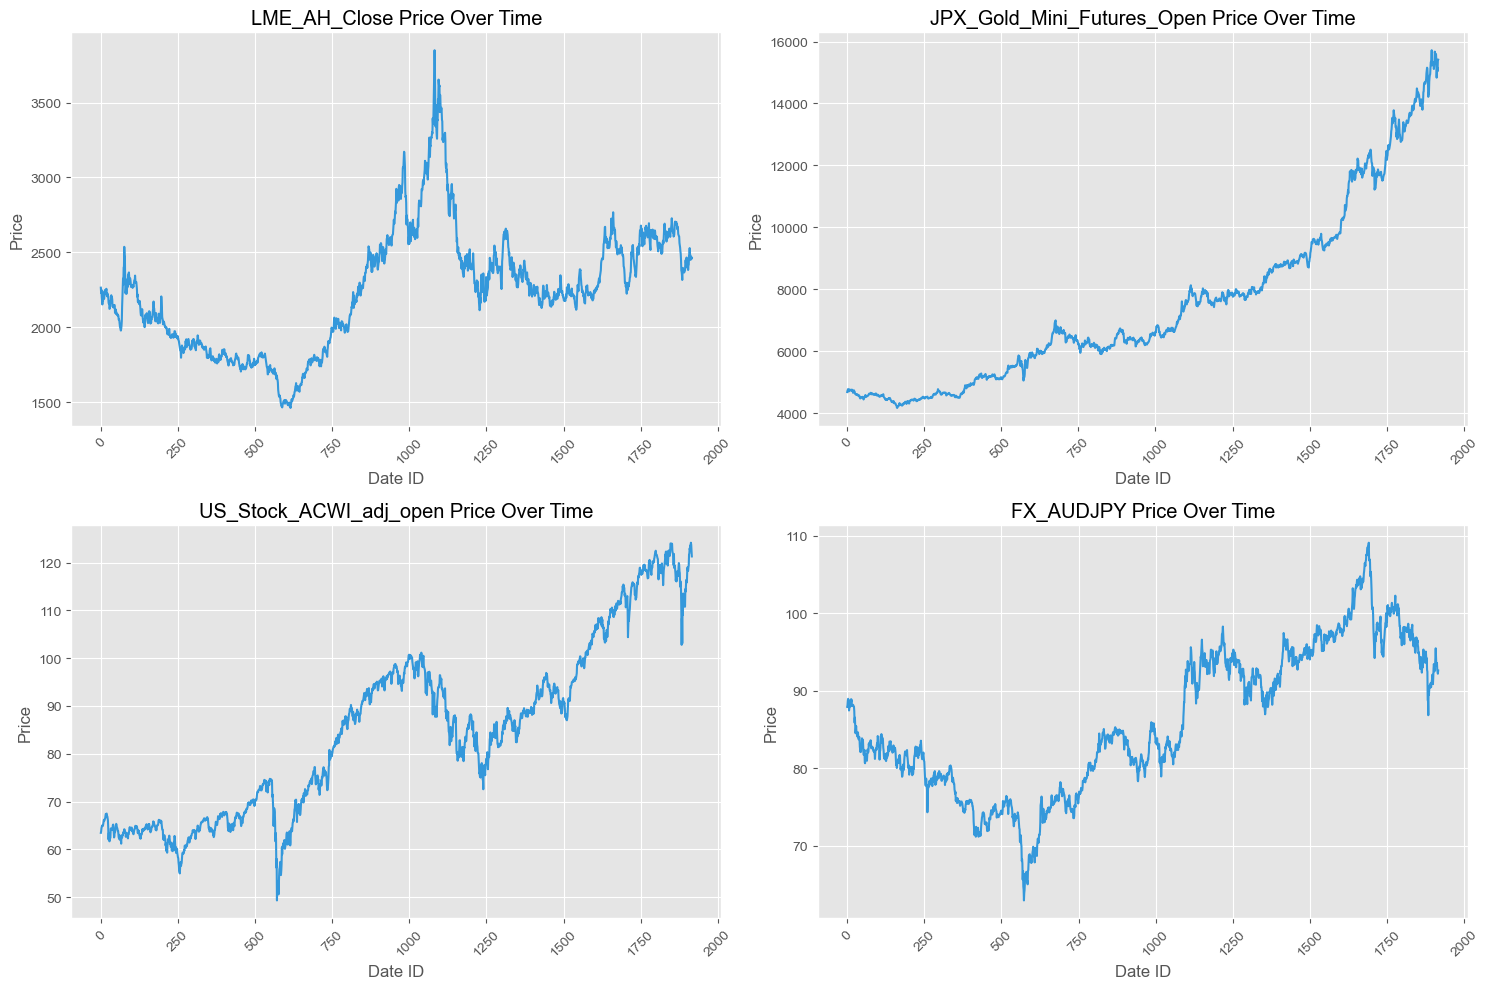

In [11]:
# 視覚化のために、さまざまな取引所からいくつかの商品を選択する
sample_instruments = []
for exchange, instruments in exchange_prefixes.items():
    if len(instruments) > 0:
        sample_instruments.append(instruments[0])

# 価格の視覚化のためのサブプロットを作成する
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, instrument in enumerate(sample_instruments[:4]):
    if instrument in train_df.columns:
        instrument_data = train_df[['date_id', instrument]].dropna()

        if len(instrument_data) > 0:
            axes[i].plot(instrument_data['date_id'], instrument_data[instrument])
            axes[i].set_title(f'{instrument} Price Over Time')
            axes[i].set_xlabel('Date ID')
            axes[i].set_ylabel('Price')
            axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## ターゲット分布分析

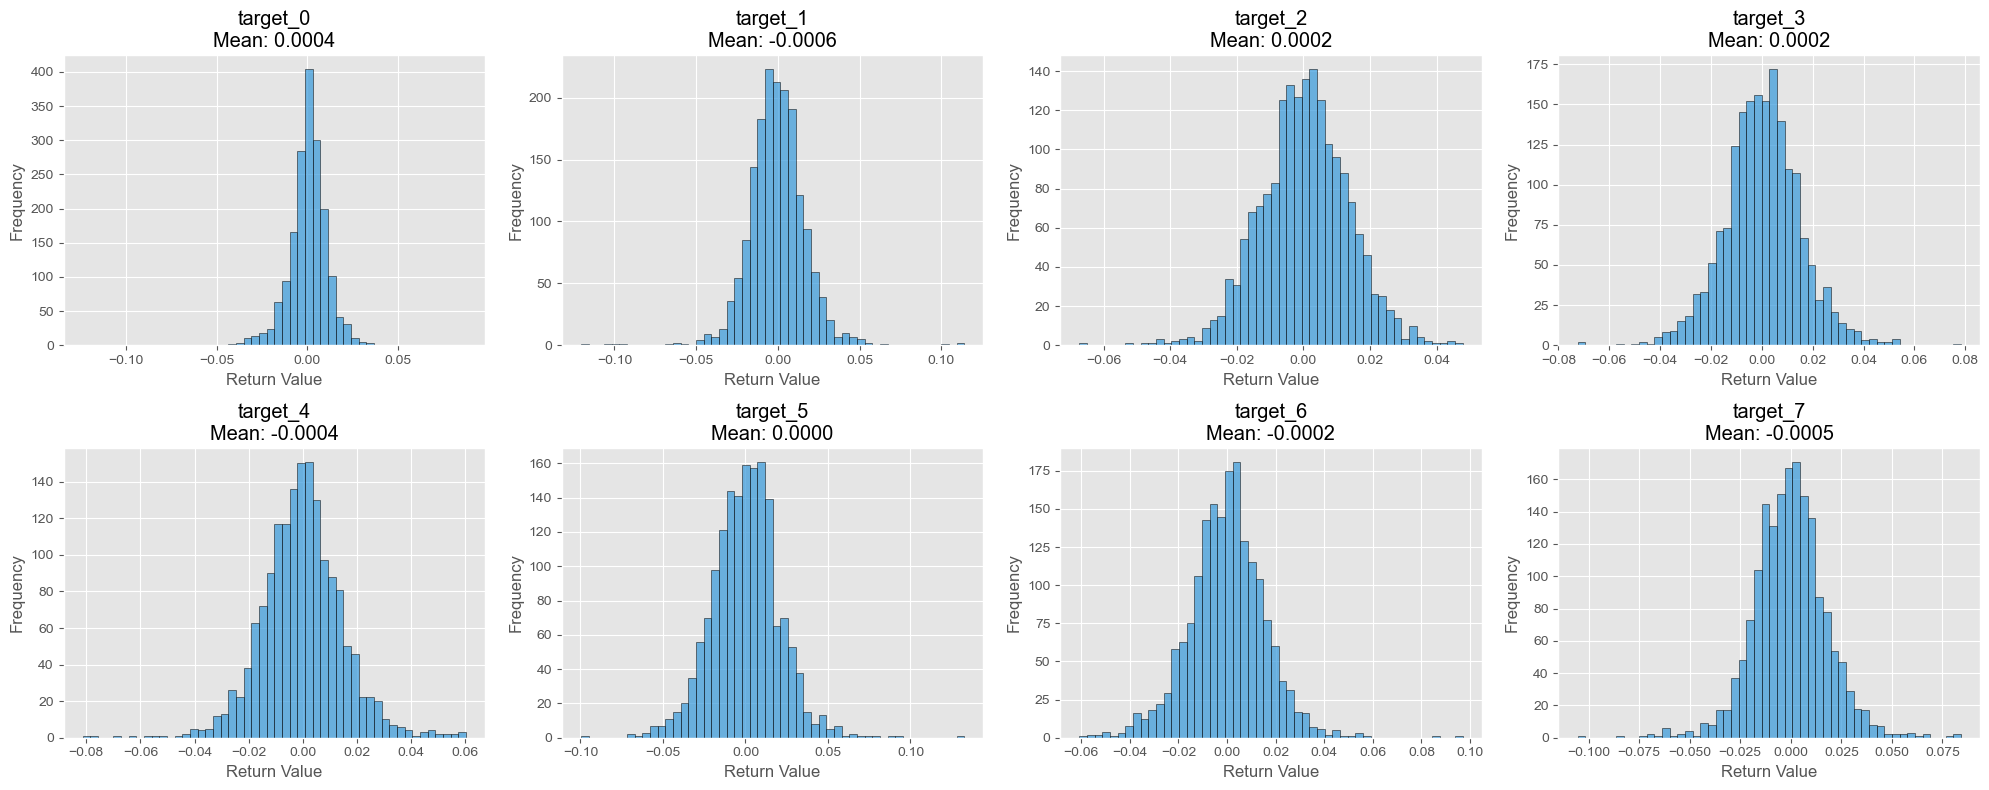

<Target Statistics Summary>
            mean     std     min     max    skew  non_null_count
target_0  0.0004  0.0120 -0.1238  0.0875 -0.9962          1787.0
target_1 -0.0006  0.0171 -0.1204  0.1140  0.0357          1744.0
target_2  0.0002  0.0131 -0.0673  0.0478 -0.1237          1831.0
target_3  0.0002  0.0150 -0.0725  0.0783  0.0184          1831.0
target_4 -0.0004  0.0150 -0.0813  0.0603  0.0082          1631.0
target_5  0.0000  0.0205 -0.0997  0.1326  0.1822          1631.0
target_6 -0.0002  0.0157 -0.0608  0.0969  0.1113          1831.0
target_7 -0.0005  0.0181 -0.1054  0.0841 -0.0487          1744.0


In [12]:
# Get sample of targets for analysis
target_cols = [col for col in train_lbl_df.columns if col.startswith('target_')]
sample_targets = target_cols[:8]  # Analyze first 8 targets

# Create distribution plots
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

target_stats = {}

for i, target in enumerate(sample_targets):
    target_data = train_lbl_df[target].dropna()
    
    if len(target_data) > 0:
        # Calculate statistics
        target_stats[target] = {
            'mean': target_data.mean(),
            'std': target_data.std(),
            'min': target_data.min(),
            'max': target_data.max(),
            'skew': target_data.skew(),
            'non_null_count': len(target_data)
        }
        
        # Plot distribution
        axes[i].hist(target_data, bins=50, alpha=0.7, edgecolor='black')
        axes[i].set_title(f'{target}\nMean: {target_data.mean():.4f}')
        axes[i].set_xlabel('Return Value')
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Print target statistics
print("<Target Statistics Summary>")
stats_df = pd.DataFrame(target_stats).T
print(stats_df.round(4))


## 相関分析

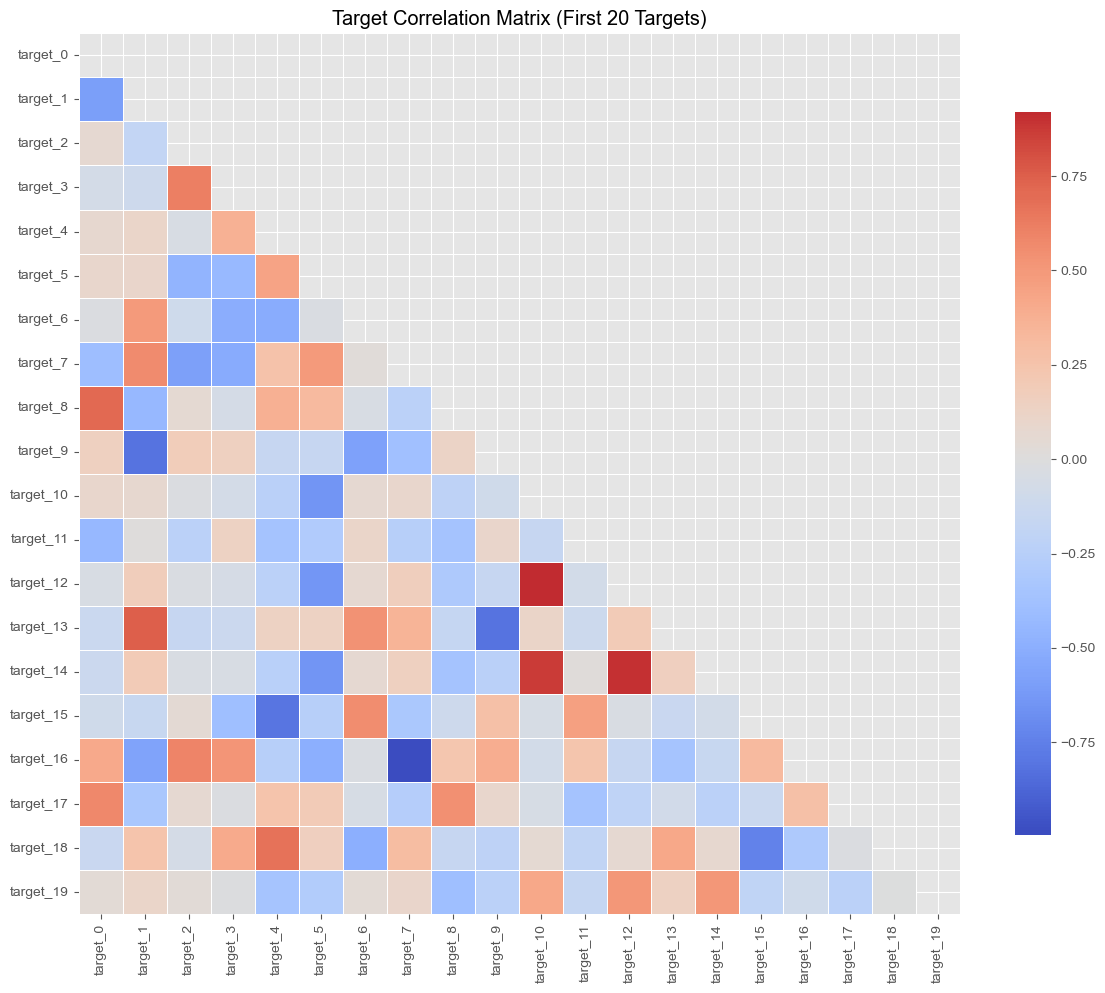


🔗 High correlation pairs (|r| > 0.7):
     Target1    Target2  Correlation
4   target_7  target_16    -0.997079
6  target_10  target_12     0.919279
8  target_12  target_14     0.902088
7  target_10  target_14     0.867986
5   target_9  target_13    -0.816955
1   target_1   target_9    -0.810036
3   target_4  target_15    -0.803220
2   target_1  target_13     0.749919
9  target_15  target_18    -0.739583
0   target_0   target_8     0.712584


In [13]:
# Select a subset of targets for correlation analysis (to avoid overwhelming)
correlation_targets = target_cols[:20]
correlation_data = train_lbl_df[correlation_targets].corr()

# Create correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_data, dtype=bool))
sns.heatmap(correlation_data, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Target Correlation Matrix (First 20 Targets)')
plt.tight_layout()
plt.show()

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(correlation_data.columns)):
    for j in range(i+1, len(correlation_data.columns)):
        corr_val = correlation_data.iloc[i, j]
        if abs(corr_val) > 0.7:  # High correlation threshold
            high_corr_pairs.append({
                'Target1': correlation_data.columns[i],
                'Target2': correlation_data.columns[j],
                'Correlation': corr_val
            })

if high_corr_pairs:
    print(f"\n🔗 High correlation pairs (|r| > 0.7):")
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(high_corr_df.head(10))

## ボラティリティー分析
ボラティリティとは、金融資産の価格変動率を意味します。市場の値動きの激しさを示し、値幅を稼ぎやすい環境かどうかを判断する材料になります。

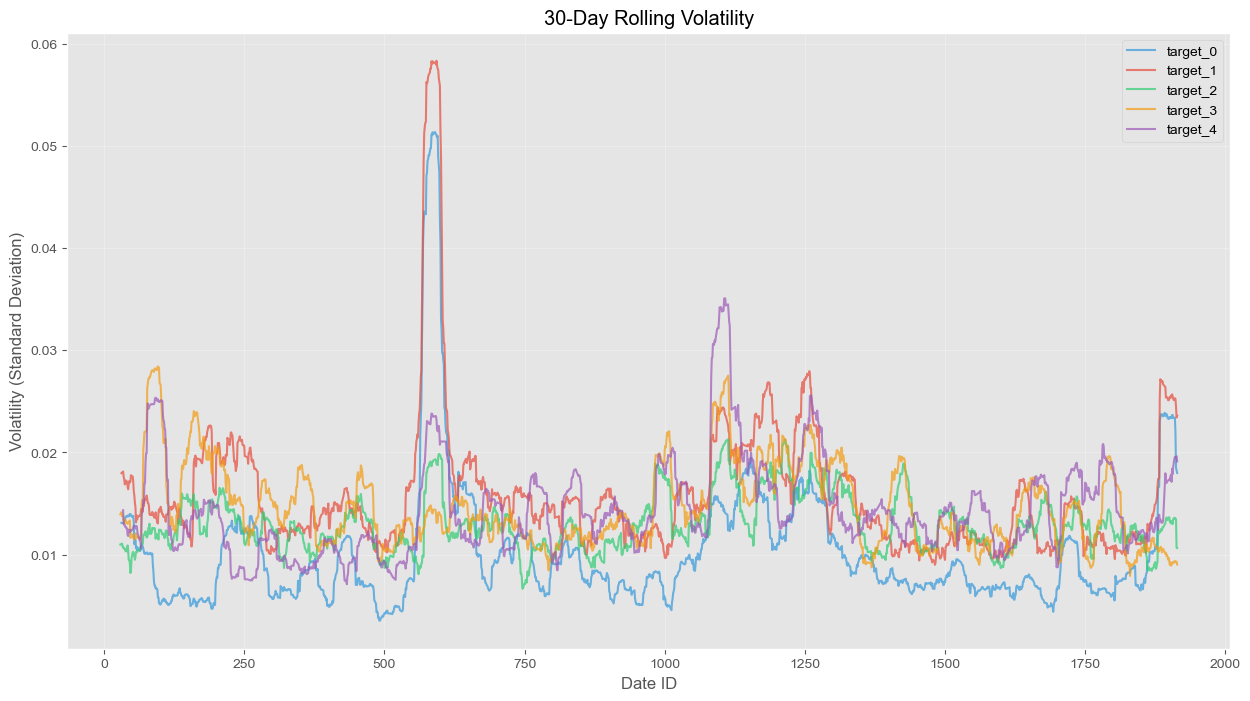

<Most volatile targets>
         Target  Volatility
411  target_411    0.075032
393  target_393    0.073611
335  target_335    0.072846
404  target_404    0.072375
329  target_329    0.071203
352  target_352    0.070859
343  target_343    0.068704
357  target_357    0.067308
235  target_235    0.063576
224  target_224    0.063458
<Least volatile targets>
         Target  Volatility
45    target_45    0.012243
153  target_153    0.012084
0      target_0    0.012029
318  target_318    0.011847
71    target_71    0.010401
44    target_44    0.009971
70    target_70    0.009734
19    target_19    0.009686
81    target_81    0.009541
68    target_68    0.009166


In [14]:
# Calculate rolling volatility for sample targets
volatility_window = 30  # 30-day rolling window
sample_targets_vol = target_cols[:5]

volatility_data = {}
for target in sample_targets_vol:
    target_series = train_lbl_df.set_index('date_id')[target].dropna()
    if len(target_series) > volatility_window:
        rolling_vol = target_series.rolling(window=volatility_window).std()
        volatility_data[target] = rolling_vol

# Plot volatility over time
if volatility_data:
    plt.figure(figsize=(15, 8))
    for target, vol_series in volatility_data.items():
        plt.plot(vol_series.index, vol_series, label=target, alpha=0.7)
    
    plt.title(f'{volatility_window}-Day Rolling Volatility')
    plt.xlabel('Date ID')
    plt.ylabel('Volatility (Standard Deviation)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Calculate average volatility by target
avg_volatility = {}
for target in target_cols:
    target_data = train_lbl_df[target].dropna()
    if len(target_data) > 0:
        avg_volatility[target] = target_data.std()

# Sort and display most/least volatile targets
vol_df = pd.DataFrame(list(avg_volatility.items()), columns=['Target', 'Volatility'])
vol_df = vol_df.sort_values('Volatility', ascending=False)

print("<Most volatile targets>")
print(vol_df.head(10))

print("<Least volatile targets>")
print(vol_df.tail(10))

## 特徴量エンジニアリング

## モデル構築

## 最後に
ここまで読んでいただきありがとうございました。私はデータ分析の学習のためにkaggleのコンペティションに参加しています。何かアドバイスや疑問点があればお気軽にコメントしてください。日本語でも英語でもどちらでも対応しています。...